# River Flow Forecasting with Data Assimilation using googlehydrology & Caravan-MultiMet

This notebook demonstrates state-of-the-art hydrological streamflow forecasting and **Data Assimilation State Data Assimilation** using the **Google Hydrology** framework in combination with the **Caravan-MultiMet** multi-product meteorological dataset.

### Why Caravan-MultiMet?
Traditional hydrological deep learning workflows (such as standard Caravan) rely exclusively on single-source reanalysis data (e.g. ERA5-Land). In operational forecasting, models must ingest **real-time nowcasts** and **numerical weather prediction (NWP) / AI forecast trajectories**:
* **Nowcasts / Near-Real-Time Data**: Precipitation from **CPC** (`cpc_precipitation`), **IMERG** (`imerg_precipitation`), and **CHIRPS** (`chirps_precipitation`).
* **Weather Forecasts**: High-resolution operational forecasts from **ECMWF HRES** (`hres_temperature_2m`, `hres_total_precipitation`, radiation, pressure) and AI-driven medium-range forecasts from **DeepMind GraphCast** (`graphcast_temperature_2m`, `graphcast_total_precipitation`).
* **Reanalysis Baselines**: High-resolution historical reanalysis from **ERA5-Land**.

### Key Pipeline Highlights
1. **Multi-Source Meteorological Ingestion**: Direct loading of MultiMet Zarr stores for operational weather nowcasts and forecasts.
2. **Google Hydrology Foundation Model**: Inference with pretrained `MeanEmbeddingForecastLSTM` using multi-source weather forcings and 84 static basin attributes.
3. **Data Assimilation**: Dynamic gradient-based state updating of hidden cell states ($c_n$) over moving windows to reconcile model trajectories with observed streamflow.
4. **Multi-Lead-Time Forecasting**: Evaluating sliding-window Data Assimilation forecasts at $L = 1, 3, 5$ days ahead with MultiMet forecast products.
5. **Multi-Basin Generalization**: End-to-end evaluation pipeline demonstrating consistent loss reduction and skill retention across diverse catchments.


In [1]:
import os
import sys
from pathlib import Path
import datetime
import glob
import yaml
import numpy as np
import pandas as pd
import xarray as xr
import torch
import matplotlib.pyplot as plt

# Ensure local googlehydrology repository is discoverable in PYTHONPATH
repo_root = Path.cwd()
for candidate in [repo_root, repo_root.parent, repo_root.parent.parent]:
    if (candidate / 'googlehydrology').exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

from googlehydrology.utils.config import Config
from googlehydrology.modelzoo.mean_embedding_forecast_lstm import MeanEmbeddingForecastLSTM
from googlehydrology.utils.assimilationconfig import AssimilationConfig
from googlehydrology.evaluation.assimilation import Assimilation

print(f"PyTorch Version: {torch.__version__} | CUDA Available: {torch.cuda.is_available()}")
print(f"xarray Version: {xr.__version__}")


PyTorch Version: 2.5.1 | CUDA Available: False
xarray Version: 2025.12.0


## Step 1: Loading MultiMet Weather Forcing Products & Caravan Catchment Data

In this step, we load meteorological forcings from the **Caravan-MultiMet** dataset (stored as Zarr archives in `/usr/local/google/home/kruparell/Caravans_MultiMet`) alongside catchment attributes and observed streamflow from Caravan.


In [2]:
# MultiMet & Caravans Data Directories
MULTIMET_DIR = Path('/usr/local/google/home/kruparell/Caravans_MultiMet')
CARAVAN_DIR = Path('/usr/local/google/home/kruparell/Caravans_V2')
STREAMFLOW_ZARR = CARAVAN_DIR / 'streamflow.zarr'
ATTRIBUTES_ZARR = CARAVAN_DIR / 'attributes.zarr'
PRIMARY_BASIN_ID = 'camels_12451000'

# Date range specifically for 1-Year MultiMet plot visualization below
PLOT_START_DATE = '2020-01-01'
PLOT_END_DATE = '2020-12-31'

def load_caravan_attributes(attr_path=ATTRIBUTES_ZARR):
    """Loads static catchment attributes directly from Zarr store."""
    try:
        ds_attr = xr.open_zarr(attr_path, consolidated=True)
    except Exception:
        ds_attr = xr.open_zarr(attr_path)
    df = ds_attr.to_dataframe()
    return df

def load_multimet_dataset(basin_id, start_date='2020-01-01', end_date='2020-12-31', leadtime=0):
    hres_ds = xr.open_zarr(MULTIMET_DIR / 'HRES/timeseries.zarr', consolidated=True).sel(basin=basin_id, date=slice(start_date, end_date))
    graphcast_ds = xr.open_zarr(MULTIMET_DIR / 'GRAPHCAST/timeseries.zarr', consolidated=True).sel(basin=basin_id, date=slice(start_date, end_date))
    cpc_ds = xr.open_zarr(MULTIMET_DIR / 'CPC/timeseries.zarr', consolidated=True).sel(basin=basin_id, date=slice(start_date, end_date))
    imerg_ds = xr.open_zarr(MULTIMET_DIR / 'IMERG/timeseries.zarr', consolidated=True).sel(basin=basin_id, date=slice(start_date, end_date))
    era5_ds = xr.open_zarr(MULTIMET_DIR / 'ERA5_LAND/timeseries.zarr', consolidated=True).sel(basin=basin_id, date=slice(start_date, end_date))

    multimet_dict = {
        'hres_surface_net_solar_radiation': hres_ds['hres_surface_net_solar_radiation'].isel(lead_time=leadtime).values.astype(np.float32),
        'hres_surface_net_thermal_radiation': hres_ds['hres_surface_net_thermal_radiation'].isel(lead_time=leadtime).values.astype(np.float32),
        'hres_surface_pressure': hres_ds['hres_surface_pressure'].isel(lead_time=leadtime).values.astype(np.float32),
        'hres_temperature_2m': hres_ds['hres_temperature_2m'].isel(lead_time=leadtime).values.astype(np.float32),
        'hres_total_precipitation': hres_ds['hres_total_precipitation'].isel(lead_time=leadtime).values.astype(np.float32),
        'graphcast_temperature_2m': graphcast_ds['graphcast_temperature_2m'].isel(lead_time=leadtime).values.astype(np.float32),
        'graphcast_total_precipitation': graphcast_ds['graphcast_total_precipitation'].isel(lead_time=leadtime).values.astype(np.float32),
        'cpc_precipitation': cpc_ds['cpc_precipitation'].values.astype(np.float32),
        'imerg_precipitation': imerg_ds['imerg_precipitation'].values.astype(np.float32),
        'era5land_total_precipitation': era5_ds['era5land_total_precipitation'].values.astype(np.float32),
        'era5land_temperature_2m': era5_ds['era5land_temperature_2m'].values.astype(np.float32),
        'era5land_surface_net_solar_radiation': era5_ds['era5land_surface_net_solar_radiation'].values.astype(np.float32),
        'era5land_surface_net_thermal_radiation': era5_ds['era5land_surface_net_thermal_radiation'].values.astype(np.float32),
        'era5land_surface_pressure': era5_ds['era5land_surface_pressure'].values.astype(np.float32),
    }
    return multimet_dict

caravan_attrs = load_caravan_attributes()
print(f"Loaded Caravans attributes for {len(caravan_attrs)} catchments.")

# Open Caravans streamflow Zarr store
ds_streamflow = xr.open_zarr(STREAMFLOW_ZARR, consolidated=True)
ds_caravan = ds_streamflow.sel(basin=PRIMARY_BASIN_ID)

# Slice 1 year specifically for plot visualization
ds_plot = ds_caravan.sel(date=slice(PLOT_START_DATE, PLOT_END_DATE))
obs_discharge_mmday = ds_plot['streamflow'].values.astype(np.float32)
dates = pd.to_datetime(ds_plot['date'].values)

multimet_vars = load_multimet_dataset(PRIMARY_BASIN_ID, PLOT_START_DATE, PLOT_END_DATE, leadtime=0)

df_data = pd.DataFrame({
    'date': dates,
    'hres_precip_mm': multimet_vars['hres_total_precipitation'],
    'graphcast_precip_mm': multimet_vars['graphcast_total_precipitation'],
    'cpc_precip_mm': multimet_vars['cpc_precipitation'],
    'imerg_precip_mm': multimet_vars['imerg_precipitation'],
    'era5_precip_mm': multimet_vars['era5land_total_precipitation'],
    'hres_temp_c': multimet_vars['hres_temperature_2m'],
    'graphcast_temp_c': multimet_vars['graphcast_temperature_2m'],
    'observed_discharge_mmday': obs_discharge_mmday
}).set_index('date')

caravan_start = pd.to_datetime(ds_caravan.date.values[0]).strftime('%Y-%m-%d')
caravan_end = pd.to_datetime(ds_caravan.date.values[-1]).strftime('%Y-%m-%d')
print(f"Selected Primary Basin: {PRIMARY_BASIN_ID}")
print(f"Full Caravan dataset available from {caravan_start} to {caravan_end}.")
print(f"Extracted {len(dates)} daily records for plot ({PLOT_START_DATE} to {PLOT_END_DATE}).")
df_data.head(5)

Loaded Caravans attributes for 24883 catchments.


/tmp/ipykernel_3307511/435678178.py:22: FutureWarning: In a future version, xarray will not decode the variable 'lead_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  hres_ds = xr.open_zarr(MULTIMET_DIR / 'HRES/timeseries.zarr', consolidated=True).sel(basin=basin_id, date=slice(start_date, end_date))
/tmp/ipykernel_3307511/435678178.py:23: FutureWarning: In a future version, xarray will not decode the variable 'lead_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of 

Selected Primary Basin: camels_12451000
Full Caravan dataset available from 1908-02-02 to 2026-03-06.
Extracted 366 daily records for plot (2020-01-01 to 2020-12-31).


,hres_precip_mm,graphcast_precip_mm,cpc_precip_mm,imerg_precip_mm,era5_precip_mm,hres_temp_c,graphcast_temp_c,observed_discharge_mmday
date,,,,,,,,
2020-01-01,34.128620,26.205915,33.923058,12.326733,38.313927,-0.908691,-1.549042,1.398146
2020-01-02,7.783261,7.070714,9.592145,1.504110,7.439404,-4.322876,-5.002716,1.315380
2020-01-03,14.475838,13.748298,6.930509,7.827780,14.246120,-1.248962,-1.837341,1.250350
2020-01-04,23.202261,17.084986,10.363290,9.864579,26.720428,-2.566620,-3.511444,1.424749
2020-01-05,10.584279,8.360472,8.155814,0.605608,11.863195,-4.711304,-5.598846,1.347895


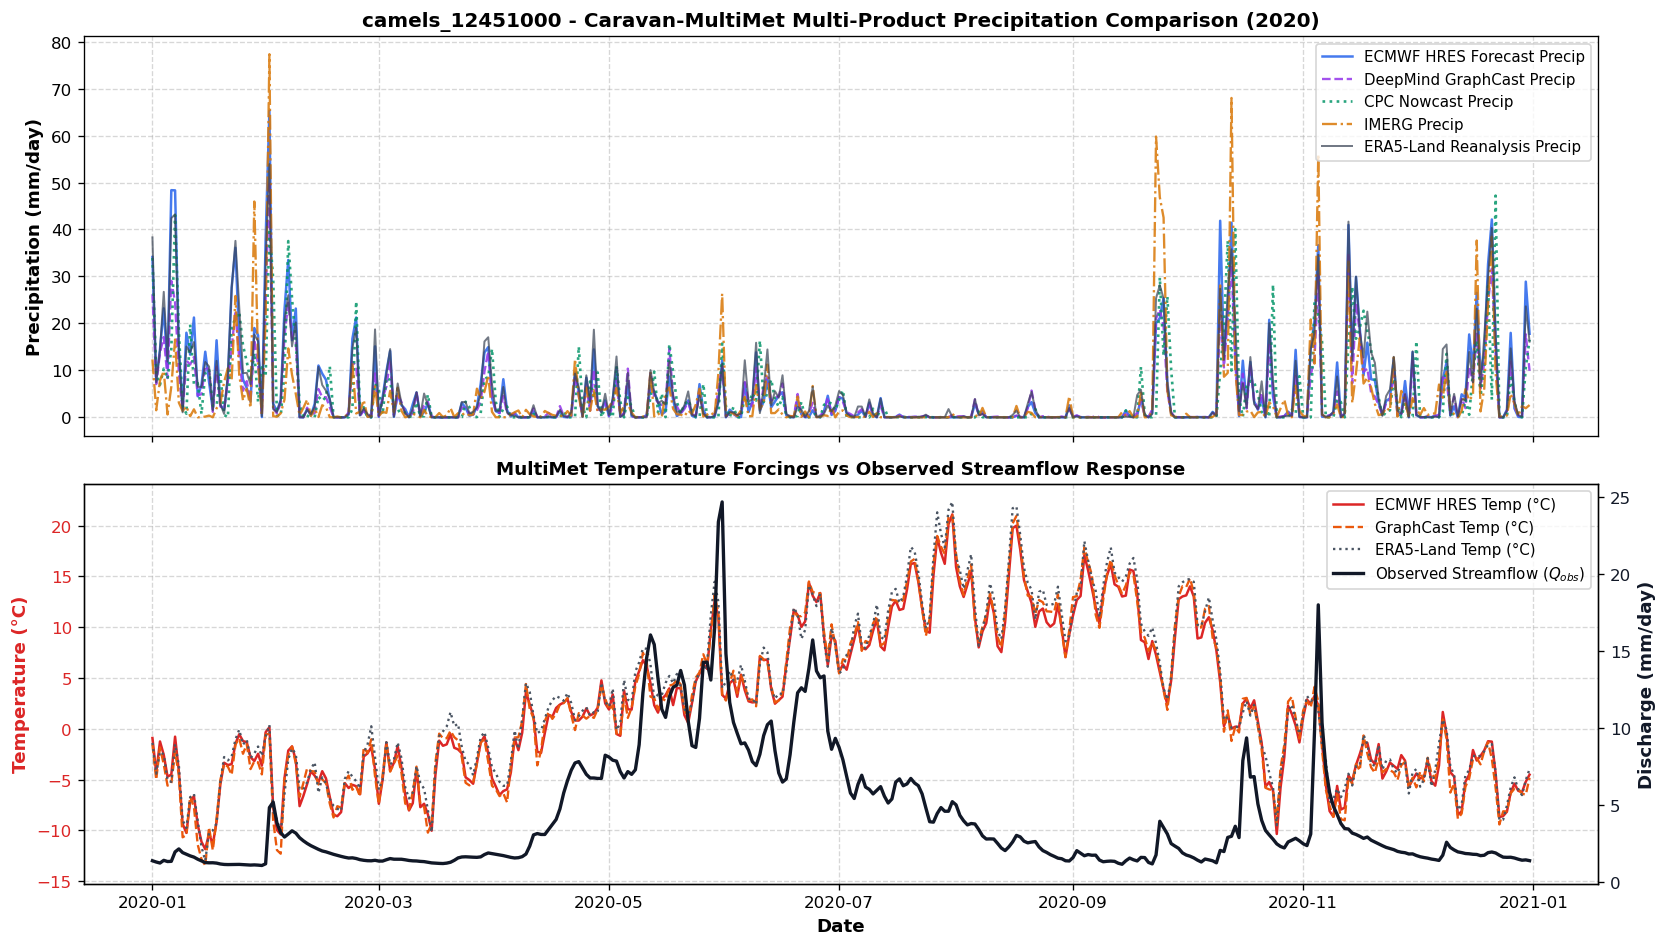

In [3]:
%matplotlib inline
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, dpi=120)

# Panel 1: MultiMet Precipitation Comparison
ax1.plot(dates, multimet_vars['hres_total_precipitation'], label='ECMWF HRES Forecast Precip', color='#2563eb', linewidth=1.5, alpha=0.85)
ax1.plot(dates, multimet_vars['graphcast_total_precipitation'], label='DeepMind GraphCast Precip', color='#9333ea', linestyle='--', linewidth=1.4, alpha=0.85)
ax1.plot(dates, multimet_vars['cpc_precipitation'], label='CPC Nowcast Precip', color='#059669', linestyle=':', linewidth=1.6, alpha=0.85)
ax1.plot(dates, multimet_vars['imerg_precipitation'], label='IMERG Precip', color='#d97706', linestyle='-.', linewidth=1.4, alpha=0.85)
ax1.plot(dates, multimet_vars['era5land_total_precipitation'], label='ERA5-Land Reanalysis Precip', color='#374151', linewidth=1.2, alpha=0.7)
ax1.set_title(f"{PRIMARY_BASIN_ID} - Caravan-MultiMet Multi-Product Precipitation Comparison (2020)", fontsize=12, fontweight="bold")
ax1.set_ylabel("Precipitation (mm/day)", fontsize=11, fontweight="bold")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper right", frameon=True, fontsize=9)

# Panel 2: MultiMet Temperature vs Observed Streamflow
ax2.plot(dates, multimet_vars['hres_temperature_2m'], label='ECMWF HRES Temp (°C)', color='#dc2626', linewidth=1.5)
ax2.plot(dates, multimet_vars['graphcast_temperature_2m'], label='GraphCast Temp (°C)', color='#ea580c', linestyle='--', linewidth=1.4)
ax2.plot(dates, multimet_vars['era5land_temperature_2m'], label='ERA5-Land Temp (°C)', color='#4b5563', linestyle=':', linewidth=1.4)
ax2.set_ylabel("Temperature (°C)", fontsize=11, fontweight="bold", color='#dc2626')
ax2.tick_params(axis='y', labelcolor='#dc2626')
ax2.grid(True, linestyle="--", alpha=0.5)

ax2_q = ax2.twinx()
ax2_q.plot(dates, obs_discharge_mmday, label="Observed Streamflow ($Q_{obs}$)", color="#111827", linewidth=2.0)
ax2_q.set_ylabel("Discharge (mm/day)", fontsize=11, fontweight="bold", color="#111827")
ax2_q.tick_params(axis='y', labelcolor="#111827")

lines_2, labels_2 = ax2.get_legend_handles_labels()
lines_q, labels_q = ax2_q.get_legend_handles_labels()
ax2.legend(lines_2 + lines_q, labels_2 + labels_q, loc="upper right", frameon=True, fontsize=9)

ax2.set_title("MultiMet Temperature Forcings vs Observed Streamflow Response", fontsize=11, fontweight="bold")
ax2.set_xlabel("Date", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


## Step 2: Pretrained Google Hydrology Foundation Model (`MeanEmbeddingForecastLSTM`) & MultiMet Feature Encoding

Here we load the pretrained `MeanEmbeddingForecastLSTM` neural network checkpoint and `scaler.nc` normalization statistics. We map MultiMet forecast and nowcast variables to model inputs.


In [5]:
PRETRAINED_DIR = Path('/usr/local/google/home/kruparell/openhydronets_next/pretrained-models/google-floodhub-settings-55-epochs-nse-filtered-0.5-85-epochs')
if not PRETRAINED_DIR.exists():
    PRETRAINED_DIR = Path('/usr/local/google/home/kruparell/flood-forecasting/pretrained-models/google-floodhub-settings-55-epochs-nse-filtered-0.5-85-epochs')

CONFIG_PATH = PRETRAINED_DIR / 'config.yml'
CHECKPOINT_PATH = PRETRAINED_DIR / 'model_epoch085.pt'
SCALER_PATH_ZARR = PRETRAINED_DIR / 'scaler.zarr'
SCALER_PATH_NC = PRETRAINED_DIR / 'scaler.nc'

# 1. Load Pretrained Model Config and Instantiate Model
with open(CONFIG_PATH, 'r') as f:
    cfg_dict = yaml.safe_load(f)

cfg = Config(cfg_dict)
model = MeanEmbeddingForecastLSTM(cfg)

# 2. Load Pretrained Model Checkpoint
raw_ckpt = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=False)
clean_ckpt = {k.replace('_orig_mod.', ''): v for k, v in raw_ckpt.items()}
model.load_state_dict(clean_ckpt, strict=True)
model.eval()

# 3. Load Feature Statistics Scaler & Target Discharge Stats
scaler = xr.open_zarr(SCALER_PATH_ZARR) if SCALER_PATH_ZARR.exists() else xr.open_dataset(SCALER_PATH_NC)

dates_arr = dates.strftime('%Y-%m-%d').values
q_mean = float(scaler['streamflow'].sel(parameter='mean').values)
q_std = float(scaler['streamflow'].sel(parameter='std').values)
obs_discharge_mmday = ds_caravan['streamflow'].values.astype(np.float32)
obs_q_norm = (obs_discharge_mmday - q_mean) / q_std

from multimet_helpers import (
    prepare_multimet_batch,
    compute_metrics,
    multimet_batch_generator,
    run_multibatch_da_pipeline,
)

# 4. Prepare Batch Data via multimet_helpers
MODE = 'multimet_0_and_1_to_7'
ISSUE_DATE = '2020-12-31'

batch_data = prepare_multimet_batch(
    mode=MODE,
    basin_id=PRIMARY_BASIN_ID,
    issue_date=ISSUE_DATE,
    cfg=cfg,
    scaler=scaler,
    caravan_attrs=caravan_attrs,
    ds_caravan=ds_caravan,
    forecast_product='HRES',
    hindcast_window_days=358,
    forecast_lead_days=7
)

print(f"Pretrained Model loaded successfully: {type(model).__name__}")
print(f"Discharge normalization stats: q_mean={q_mean:.4f}, q_std={q_std:.4f}")
print(f"Batch prepared using prepare_multimet_batch (mode='{MODE}', issue_date='{ISSUE_DATE}')")

Pretrained Model loaded successfully: MeanEmbeddingForecastLSTM
Discharge normalization stats: q_mean=1.7772, q_std=3.3810
Batch prepared using prepare_multimet_batch (mode='multimet_0_and_1_to_7', issue_date='2020-12-31')


## Step 3: Single-Basin Data Assimilation with MultiMet Forcings

We configure **Data Assimilation** using `AssimilationConfig` and `Assimilation`. The pipeline optimizes the LSTM cell state tensor ($c_n$) over rolling windows, aligning simulated discharge with observed flow while retaining the learned foundation dynamics.


In [6]:
cfg_dict_assim = {
    # REMEMBER: DA Period is window*history

    # Sequence layout
    'seq_length': 365,               # Total sequence (1 year)
    'history': 1,                   # Lookback / DA window step size
    'assimilation_window': 30,        # Days per update block
    
    # Timeline offsets to create the 4 visual zones:
    'assimilation_lead_time': 230,    # Phase 1 -> 2 transition (e.g., 30-day baseline/warmup offset)
    'predict_n_hindcast': 7,       # Phase 3 end (Days 30 to 130 are actively optimized)
    'predict_last_n': 24,           # Full rollout length
    
    # Optimization
    'learning_rate': 1e-1,           # Reduced slightly to prevent total state blowing up
    'epochs': 10,
    'bg_regularization_weight': 1e-6,

    # Optimisation Aims
    # 'use_per_step_updates': True,
    'optimizer': 'Adam',
    'loss': 'MSE',
    'assimilation_targets': ['c_n'],
    'target_variables': ['streamflow'],
}

assim_cfg = AssimilationConfig(cfg_dict_assim)
assim = Assimilation(assim_cfg)

assim.validate_data_structure(batch_data)
diag = assim.check_discharge_timing(batch_data, verbose=True)
print("Data structure validated successfully for MeanEmbeddingForecastLSTM!")

with torch.no_grad():
    base_out = model(batch_data)
    q_base_norm = base_out['y_hat'][0, :, 0].numpy()

da_results = assim.assimilate(model, batch_data, verbose=True)
q_da_norm = da_results['y_hat'][0, :, 0].numpy()

q_baseline = np.maximum(0.1, q_base_norm * q_std + q_mean)
q_assimilated = np.maximum(0.1, q_da_norm * q_std + q_mean)

def compute_metrics(obs, sim):
    valid = ~np.isnan(obs) & ~np.isnan(sim)
    o, s = obs[valid], sim[valid]
    denom = np.sum((o - np.mean(o)) ** 2)
    nse = float(1 - (np.sum((o - s) ** 2) / denom)) if denom != 0 else np.nan
    rmse = float(np.sqrt(np.mean((o - s) ** 2)))
    r = float(np.corrcoef(o, s)[0, 1]) if len(o) > 1 else np.nan
    std_o, std_s = np.std(o), np.std(s)
    kge = float(1 - np.sqrt((r - 1)**2 + (std_s/std_o - 1)**2 + (np.mean(s)/np.mean(o) - 1)**2)) if std_o > 0 and np.mean(o) > 0 else np.nan
    return {'NSE': nse, 'KGE': kge, 'Pearson-r': r, 'RMSE (mm/day)': rmse}


# 1. Get exact sequence of date strings from batch_data
batch_dates = batch_data['date'][0]
# 2. Extract observed streamflow (mm/day) matching batch dates
obs_discharge_mmday_chunk = ds_caravan['streamflow'].sel(date=batch_dates).values.astype(np.float32)
m_base = compute_metrics(obs_discharge_mmday_chunk, q_baseline)
m_da = compute_metrics(obs_discharge_mmday_chunk, q_assimilated)

summary_table = pd.DataFrame([
    {'Mode': 'Pretrained Foundation Model (Open-Loop, No DA)', **m_base},
    {'Mode': 'googlehydrology Assimilation (Data Assimilation State Updated)', **m_da},
]).set_index('Mode')

print(f"=== Hydrological Model Performance Comparison ({PRIMARY_BASIN_ID}) ===")
print(summary_table.to_string())

Data structure validated successfully for MeanEmbeddingForecastLSTM!
=== Hydrological Model Performance Comparison (camels_12451000) ===
                                                          NSE       KGE  Pearson-r  RMSE (mm/day)
Mode                                                                                             
Pretrained Foundation Model (Open-Loop, No DA)       0.708676  0.560630   0.928105       2.113769
googlehydrology Assimilation (Data Assimilation State Updated)  0.809607  0.755731   0.918854       1.708815


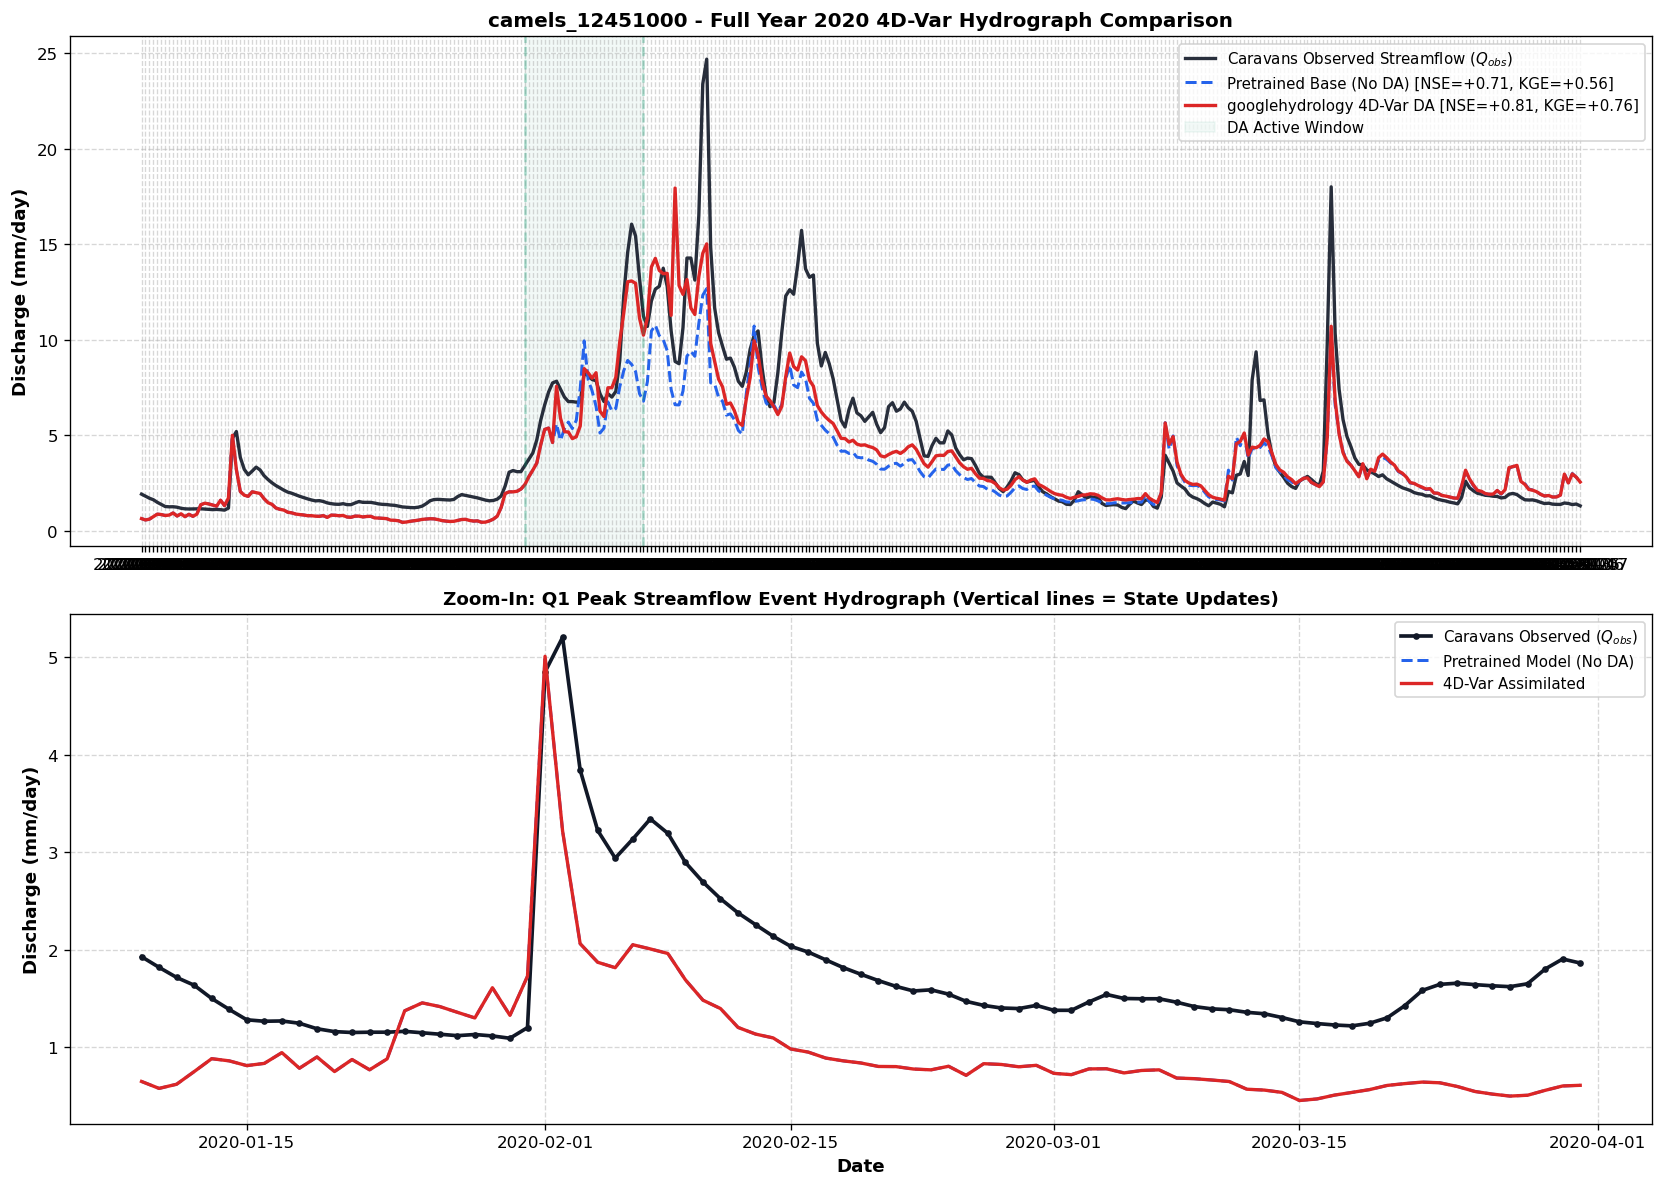

In [7]:
%matplotlib inline
# --- 1. Identify DA Timesteps and Window Boundaries ---
da_start_idx = assim._start_timestep
da_end_idx = assim._end_timestep
window_size = assim.cfg.assimilation_window



# Generate array of indices where state updates occur: [start, start + W, start + 2W, ..., end]
update_indices = list(range(da_start_idx, da_end_idx + 1, window_size))
update_dates = [dates[idx] for idx in update_indices if idx < len(dates)]

# --- 2. Plotting Setup ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), dpi=120)

# --- PANEL 1: Full Year Hydrograph ---
ax1.plot(batch_dates, obs_discharge_mmday_chunk, label="Caravans Observed Streamflow ($Q_{obs}$)", color="#111827", linewidth=2.0, alpha=0.9)
ax1.plot(batch_dates, q_baseline, label=f"Pretrained Base (No DA) [NSE={m_base['NSE']:+.2f}, KGE={m_base['KGE']:+.2f}]", color="#2563eb", linestyle="--", linewidth=1.8)
ax1.plot(batch_dates, q_assimilated, label=f"googlehydrology Data Assimilation [NSE={m_da['NSE']:+.2f}, KGE={m_da['KGE']:+.2f}]", color="#dc2626", linestyle="-", linewidth=2.0)

# Highlight active DA period shading
# Convert index boundaries to matching string dates ('YYYY-MM-DD')
da_start_date = pd.to_datetime(dates[da_start_idx]).strftime('%Y-%m-%d')
da_end_date = pd.to_datetime(dates[min(da_end_idx, len(dates)-1)]).strftime('%Y-%m-%d')

# Highlight active DA period shading
ax1.axvspan(da_start_date, da_end_date, color="#059669", alpha=0.05, label="DA Active Window")

# Draw vertical lines at every cell state update boundary
for i, dt in enumerate(update_dates):
    dt_str = pd.to_datetime(dt).strftime('%Y-%m-%d')
    ax1.axvline(dt_str, color='#059669', linestyle='--', alpha=0.3)

ax1.set_title(f"{PRIMARY_BASIN_ID} - Full Year 2020 Data Assimilation Hydrograph Comparison", fontsize=12, fontweight="bold")
ax1.set_ylabel("Discharge (mm/day)", fontsize=11, fontweight="bold")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper right", frameon=True, fontsize=9)


# --- PANEL 2: Zoom-In on Q1 Peak Flow ---
plot_dates = pd.to_datetime(batch_data['date'][0])
zoom_mask = (plot_dates >= "2020-01-01") & (plot_dates <= "2020-03-31")
zoom_dates = plot_dates[zoom_mask]

# Extract streamflow matching plot_dates
obs_plot = ds_caravan['streamflow'].sel(date=plot_dates).values.astype(np.float32)

ax2.plot(zoom_dates, obs_plot[zoom_mask], label="Caravans Observed ($Q_{obs}$)", color="#111827", linewidth=2.2, marker="o", markersize=3)
ax2.plot(zoom_dates, q_baseline[zoom_mask], label="Pretrained Model (No DA)", color="#2563eb", linestyle="--", linewidth=1.8)
ax2.plot(zoom_dates, q_assimilated[zoom_mask], label="Data Assimilation Assimilated", color="#dc2626", linewidth=2.0)
# Draw state update lines that fall within the zoom time range
zoom_min_date, zoom_max_date = zoom_dates[0], zoom_dates[-1]
for dt in update_dates:
    if zoom_min_date <= dt <= zoom_max_date:
        ax2.axvline(x=dt, color="#059669", linestyle=":", linewidth=1.5, alpha=0.85)

ax2.set_title("Zoom-In: Q1 Peak Streamflow Event Hydrograph (Vertical lines = State Updates)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Date", fontsize=11, fontweight="bold")
ax2.set_ylabel("Discharge (mm/day)", fontsize=11, fontweight="bold")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper right", frameon=True, fontsize=9)

plt.tight_layout()
plt.show()

## Step 4: Multi-Lead-Time Forecast & Data Assimilation Analysis (Lead Times $L = 0, 3, 5, 7$ Days)

In operational flood forecasting, atmospheric forcing forecasts are issued at lead times $L = 0, 1, \dots, 7$ days ahead. Below we visualize:
1. **Multi-Lead-Time Precipitation Trajectories**: Comparing ECMWF HRES daily rainfall forecasts across lead times $L = 0 \dots 7$ over the year.
2. **$2 \times 2$ Hydrograph Assimilation Performance**: Evaluating open-loop baseline vs Data Assimilation assimilated streamflow forecasts under lead times $L \in \{0, 3, 5, 7\}$ days.

<>:30: SyntaxWarning: invalid escape sequence '\D'
<>:30: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_3307511/3064035348.py:30: SyntaxWarning: invalid escape sequence '\D'
  ax_bot.set_ylabel("Diff $\Delta P$ (mm/day)", fontsize=10)
/tmp/ipykernel_3307511/3064035348.py:5: FutureWarning: In a future version, xarray will not decode the variable 'lead_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  hres_ds_full = xr.open_zarr(MULTIMET_DIR / 'HRES/timeseries.zarr').sel(basin=PRIMARY_BASIN_ID, date=slice(PLOT_START_DATE, PLOT_END_DATE))


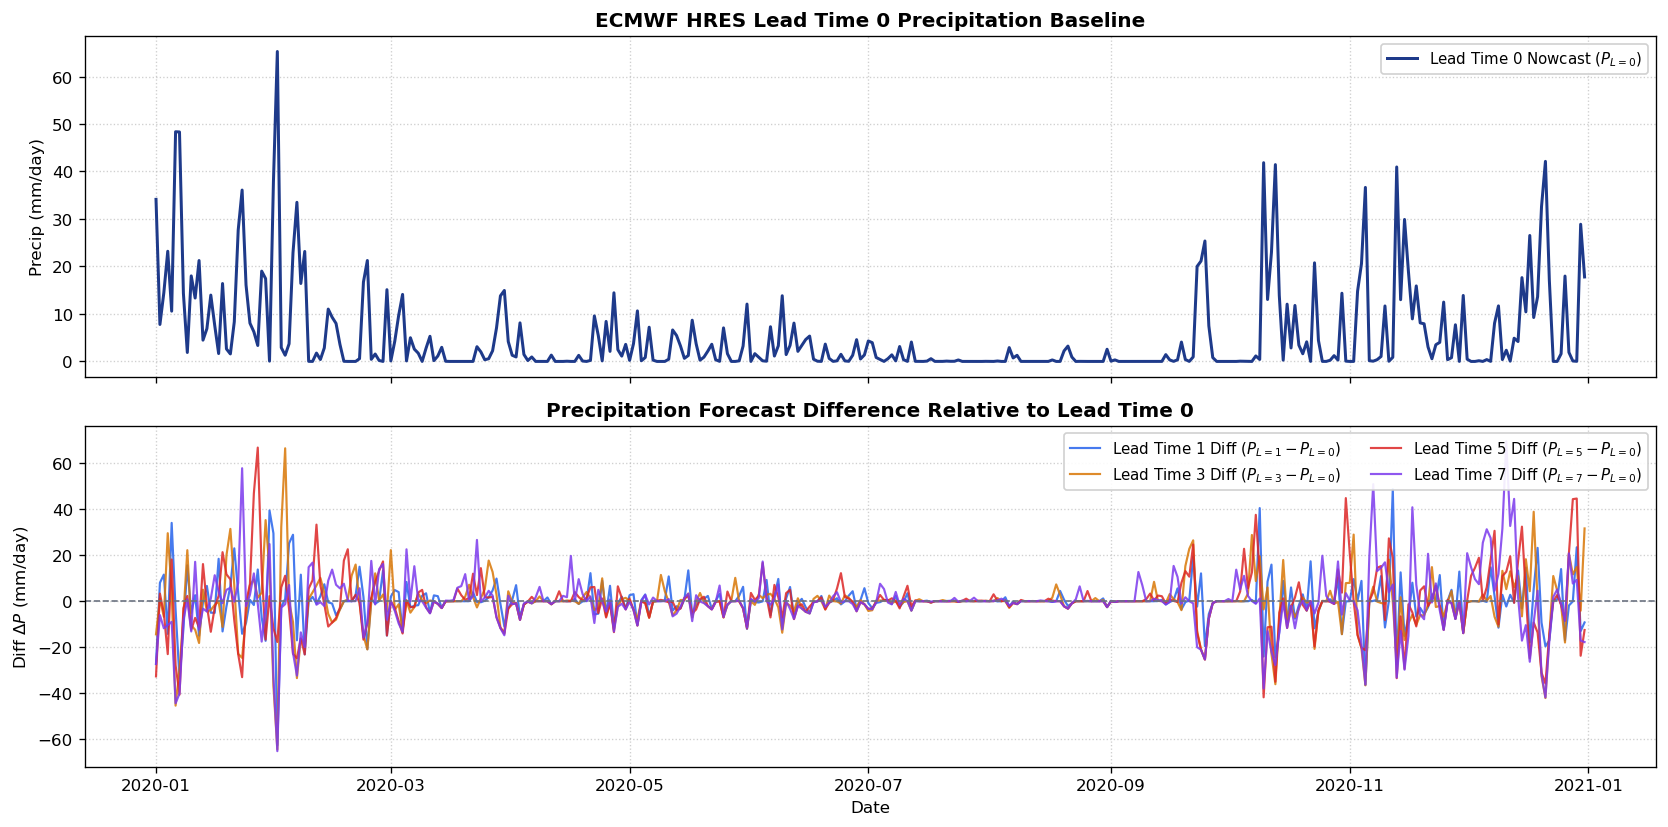

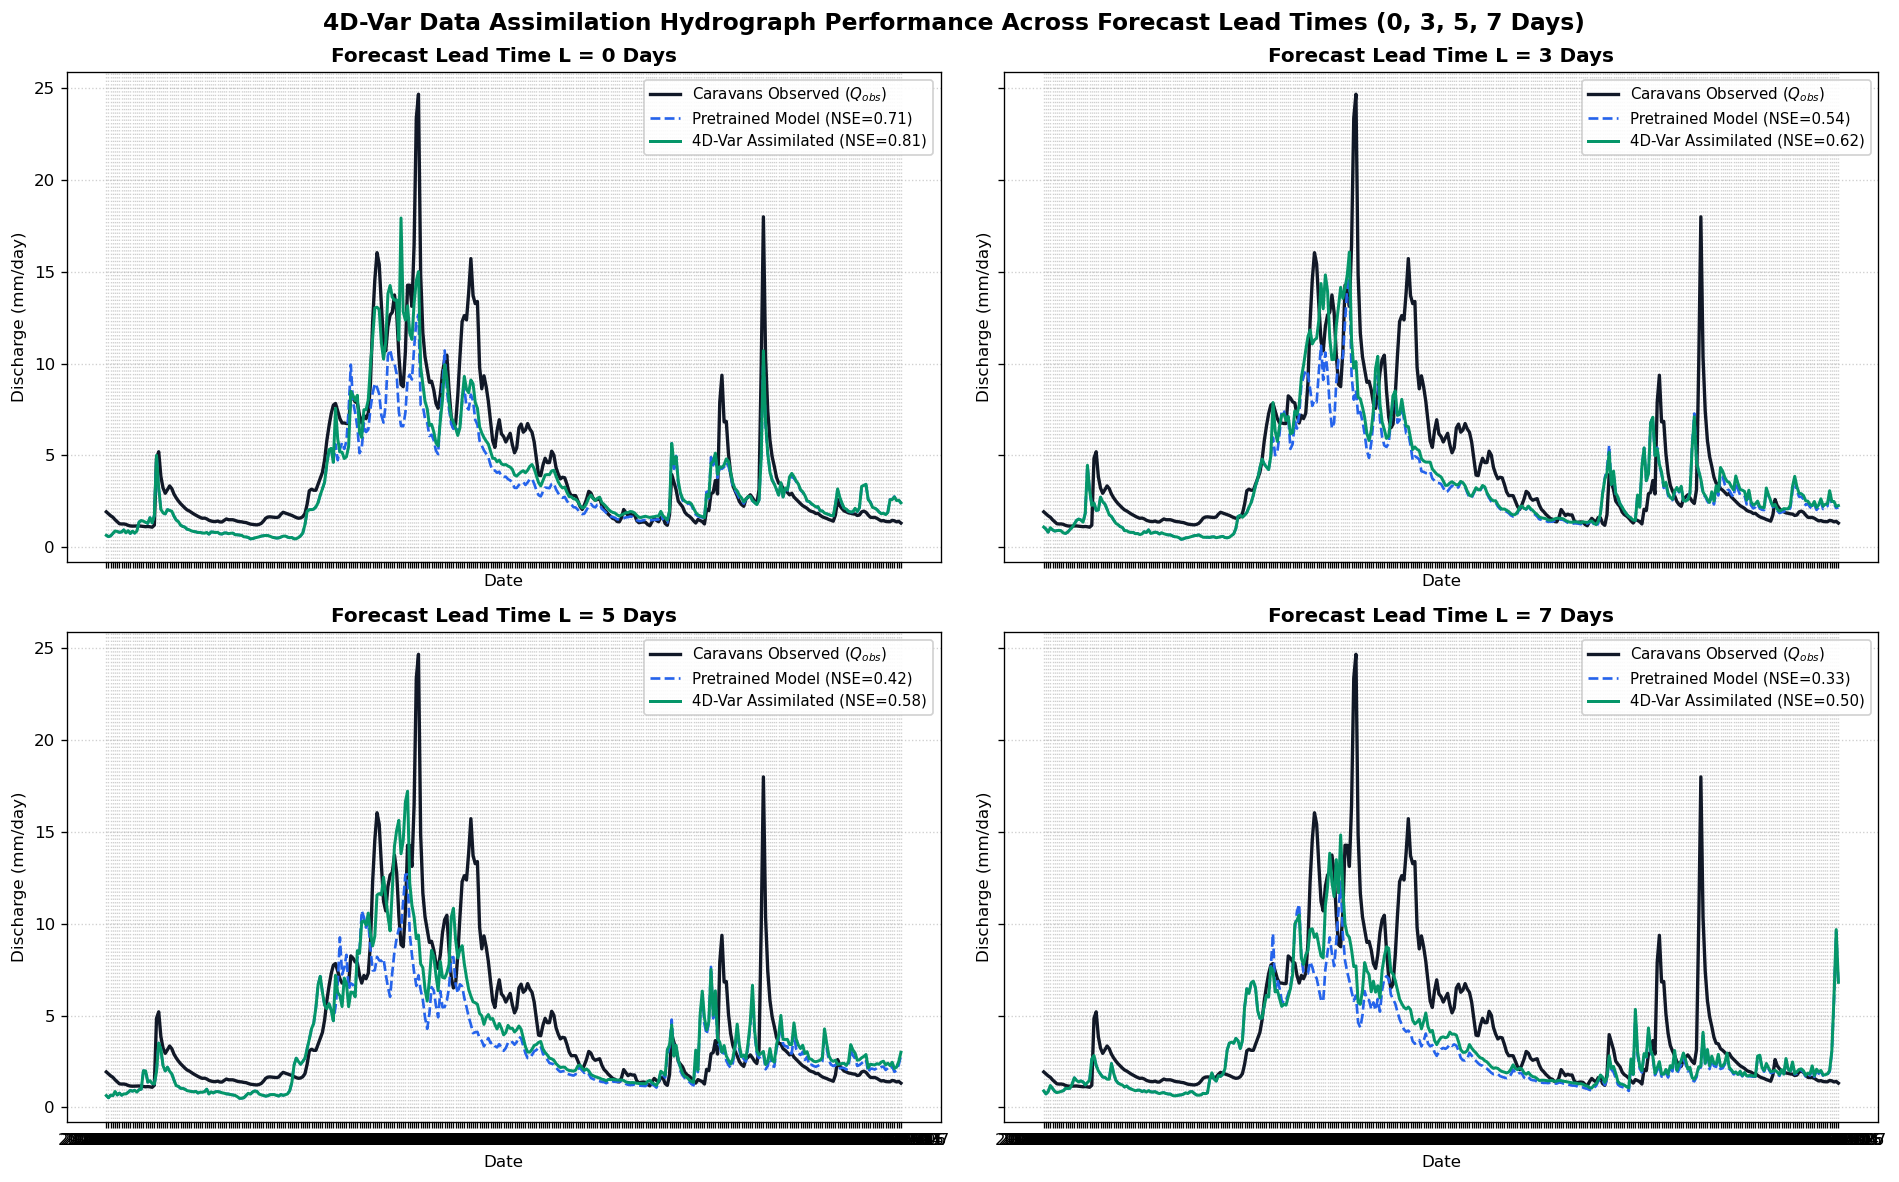

In [8]:
%matplotlib inline
import matplotlib.cm as cm

# --- Step 4 Plot 1: Leadtime 0 Precipitation Baseline & Leadtime Differences (L = 1, 3, 5, 7 vs L = 0) ---
hres_ds_full = xr.open_zarr(MULTIMET_DIR / 'HRES/timeseries.zarr').sel(basin=PRIMARY_BASIN_ID, date=slice(PLOT_START_DATE, PLOT_END_DATE))
plot_dates = pd.to_datetime(hres_ds_full['date'].values)

# Extract Leadtime 0 (Nowcast) rainfall
p_lead0 = hres_ds_full['hres_total_precipitation'].isel(lead_time=0).values.astype(np.float32)

fig1, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 7), sharex=True, dpi=120)

# Top Panel: Leadtime 0 Reference Rainfall
ax_top.plot(plot_dates, p_lead0, label="Lead Time 0 Nowcast ($P_{L=0}$)", color="#1e3a8a", linewidth=1.8)
ax_top.set_title("ECMWF HRES Lead Time 0 Precipitation Baseline", fontsize=12, fontweight="bold")
ax_top.set_ylabel("Precip (mm/day)", fontsize=10)
ax_top.grid(True, linestyle=":", alpha=0.6)
ax_top.legend(loc="upper right", framealpha=0.9, fontsize=9)

# Bottom Panel: Precipitation Difference from Leadtime 0 (P_L - P_0)
diff_colors = {1: "#2563eb", 3: "#d97706", 5: "#dc2626", 7: "#7c3aed"}

for L in [1, 3, 5, 7]:
    p_L = hres_ds_full['hres_total_precipitation'].isel(lead_time=L).values.astype(np.float32)
    diff = p_L - p_lead0
    ax_bot.plot(plot_dates, diff, label=f"Lead Time {L} Diff ($P_{{L={L}}} - P_{{L=0}}$)", color=diff_colors[L], linewidth=1.3, alpha=0.85)

ax_bot.axhline(0, color="#6b7280", linestyle="--", linewidth=1.0)
ax_bot.set_title("Precipitation Forecast Difference Relative to Lead Time 0", fontsize=12, fontweight="bold")
ax_bot.set_ylabel("Diff $\Delta P$ (mm/day)", fontsize=10)
ax_bot.set_xlabel("Date", fontsize=10)
ax_bot.grid(True, linestyle=":", alpha=0.6)
ax_bot.legend(loc="upper right", framealpha=0.9, ncol=2, fontsize=9)

plt.tight_layout()
plt.show()

# --- Step 4 Plot 2: 2x2 Subplots Hydrograph Comparison for Lead Times L = 0, 3, 5, 7 ---
lead_times_to_plot = [0, 3, 5, 7]
fig2, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True, dpi=120)
axes_flat = axes.flatten()

# Extract true streamflow observation matching batch dates
batch_dates_str = pd.to_datetime(batch_data['date'][0]).strftime('%Y-%m-%d').values
obs_plot = ds_caravan['streamflow'].sel(date=batch_dates_str).values.astype(np.float32)

for idx, L in enumerate(lead_times_to_plot):
    ax = axes_flat[idx]
    
    # 1. Prepare batch for fixed lead time L
    batch_L = prepare_multimet_batch(
        mode='reanalysis_and_fixed_leadtime',
        basin_id=PRIMARY_BASIN_ID,
        issue_date=ISSUE_DATE,
        cfg=cfg,
        scaler=scaler,
        caravan_attrs=caravan_attrs,
        ds_caravan=ds_caravan,
        forecast_product='HRES',
        fixed_leadtime=L,
        hindcast_window_days=358,
        forecast_lead_days=7
    )
    
    # 2. Compute open-loop baseline predictions (No DA)
    with torch.no_grad():
        base_out = model(batch_L)
        q_base_norm = base_out['y_hat'][0, :, 0].numpy()
    
    # 3. Compute Data Assimilation predictions
    da_results = assim.assimilate(model, batch_L, verbose=False)
    q_da_norm = da_results['y_hat'][0, :, 0].numpy()
    
    # Convert predictions to physical units (mm/day)
    q_baseline = np.maximum(0.1, q_base_norm * q_std + q_mean)
    q_assimilated = np.maximum(0.1, q_da_norm * q_std + q_mean)
    
    # Compute accuracy metrics
    m_base = compute_metrics(obs_plot, q_baseline)
    m_da = compute_metrics(obs_plot, q_assimilated)
    
    # Render hydrographs
    ax.plot(batch_dates_str, obs_plot, label="Caravans Observed ($Q_{obs}$)", color="#111827", linewidth=2.0)
    ax.plot(batch_dates_str, q_baseline, label=f"Pretrained Model (NSE={m_base['NSE']:.2f})", color="#2563eb", linestyle="--", linewidth=1.6)
    ax.plot(batch_dates_str, q_assimilated, label=f"Data Assimilation Assimilated (NSE={m_da['NSE']:.2f})", color="#059669", linewidth=1.8)
    
    ax.set_title(f"Forecast Lead Time L = {L} Days", fontsize=12, fontweight="bold")
    ax.set_ylabel("Discharge (mm/day)", fontsize=10)
    ax.set_xlabel("Date", fontsize=10)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper right", framealpha=0.9, fontsize=9)

fig2.suptitle("Data Assimilation Hydrograph Performance Across Forecast Lead Times (0, 3, 5, 7 Days)", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

In [9]:
# --- Data Assimilation Configuration ---
cfg_dict_assim = {
    # Sequence Layout & DA Window Configuration
    'seq_length': 365,               # Total sequence length (days)
    'history': 11,                    # Lookback / DA window step size (days)
    'assimilation_window': 30,      # Days per update block
    
    # Timeline Offsets
    'assimilation_lead_time': 30,    # Phase 1 -> Phase 2 transition offset
    'predict_n_hindcast': 7,         # Phase 3 end (actively optimized window)
    'predict_last_n': 24,            # Full rollout forecast length
    
    # Optimization Parameters
    'learning_rate': 1e-1,           # Adam optimizer learning rate
    'epochs': 10,                    # Optimization iterations per assimilation step
    'bg_regularization_weight': 1e-6, # Regularization penalty on initial hidden states

    # Optimization Targets & Loss
    'optimizer': 'Adam',
    'loss': 'MSE',
    'assimilation_targets': ['c_n'], # Cell states optimized in Data Assimilation
    'target_variables': ['streamflow'],
}

# Instantiate AssimilationConfig
assim_cfg = AssimilationConfig(cfg_dict_assim)

# Run multi-batch pipeline with explicit DA config
EVAL_ISSUE_DATES = ['2020-03-31', '2020-06-30', '2020-09-30', '2020-12-24']

df_leadtime_metrics, stored_hydrographs = run_multibatch_da_pipeline(
    basin_list=[PRIMARY_BASIN_ID],
    issue_dates=EVAL_ISSUE_DATES,
    da_cfg=assim_cfg,  # Passed explicitly here
    lead_times=[0, 3, 5, 7]
)

print(df_leadtime_metrics.to_string(index=False))

       Basin ID Issue Date  Lead Time (Days)  Base NSE  Base KGE  DA NSE  DA KGE  NSE Delta  KGE Delta
camels_12451000 2020-03-31                 0    -0.155    -0.082   0.953   0.936      1.108      1.018
camels_12451000 2020-03-31                 3    -0.204    -0.107   0.899   0.946      1.103      1.053
camels_12451000 2020-03-31                 5    -0.288    -0.208   0.840   0.909      1.128      1.117
camels_12451000 2020-03-31                 7    -0.399    -0.309   0.794   0.874      1.193      1.183
camels_12451000 2020-06-30                 0     0.863     0.764   0.950   0.967      0.086      0.202
camels_12451000 2020-06-30                 3     0.706     0.738   0.886   0.919      0.181      0.180
camels_12451000 2020-06-30                 5     0.653     0.730   0.850   0.895      0.197      0.165
camels_12451000 2020-06-30                 7     0.605     0.738   0.801   0.897      0.196      0.159
camels_12451000 2020-09-30                 0     0.815     0.829   0.973 

## Step 6: Multi-Basin Continuous Forecast Matrix Evaluation (`mode='multimet_0_and_1_to_7'`)

In this operational evaluation step, we generate daily forecasts in **`multimet_0_and_1_to_7` mode** across an evaluation interval (issue dates $t_0$). 

For each issue date $t_0$:
- The hindcast period ($t \le t_0$) receives Leadtime 0 nowcast forcings (with NaN masking in the final 7 days).
- The forecast period ($t_0+1 \dots t_0+7$) receives MultiMet forecast product forcings at Leadtimes $1, 2, \dots, 7$.
- The model predicts 7-day ahead streamflows ($\hat{y}_{L=1 \dots 7}$).

We construct a **Forecast Matrix** $\text{Matrix}[t_0, L]$ across issue dates, and extract the continuous **Lead-Time $N$ Hydrograph** (column $L = N$) aligned with observed streamflow $Q_{obs}$ to evaluate true operational performance (NSE & KGE) across 3 basins (`camels_12451000`, `camels_12377150`, `camels_12115000`).

In [ ]:
%matplotlib inline

# --- Step 6: Daily Rolling Forecast Matrix Evaluation for ALL Lead Times L = 1..7 ---
THREE_BASINS = ['camels_12451000', 'camels_12377150', 'camels_12115000']
EVAL_START_DATE = '2020-01-01'
EVAL_END_DATE = '2020-01-31'
ALL_LEADTIMES = list(range(1, 8))  # Evaluate ALL lead times L = 1..7

# Sample issue dates across the interval for evaluation
issue_dates_stage6 = pd.date_range(EVAL_START_DATE, EVAL_END_DATE, freq='D').strftime('%Y-%m-%d')

# Instantiate Data Assimilation engine using Step 3 DA config
assim_stage6 = Assimilation(AssimilationConfig(cfg_dict_assim))

records_base = []
records_da = []
records_metrics_stage6 = []

for b_id in THREE_BASINS:
    print(f"\nProcessing Basin: {b_id}")
    ds_b = ds_streamflow.sel(basin=b_id)
    
    current_month = None
    for dt in issue_dates_stage6:
        dt_month = pd.to_datetime(dt).strftime('%Y-%m')
        if dt_month != current_month:
            print(f"  Switched to month: {dt_month}")
            current_month = dt_month
            
        # 1. Prepare batch in multimet_0_and_1_to_7 mode
        batch_b = prepare_multimet_batch(
            mode='multimet_0_and_1_to_7',
            basin_id=b_id,
            issue_date=dt,
            cfg=cfg,
            scaler=scaler,
            caravan_attrs=caravan_attrs,
            ds_caravan=ds_b,
            forecast_product='HRES',
            hindcast_window_days=358,
            forecast_lead_days=7
        )
        
        dt_obj = pd.to_datetime(dt)
        
        # 2. Open-loop baseline forecast
        with torch.no_grad():
            b_out = model(batch_b)
            q_base_7_norm = b_out['y_hat'][0, -7:, 0].numpy()
        q_base_7 = np.maximum(0.1, q_base_7_norm * q_std + q_mean)
        
        # 3. Data Assimilation forecast
        da_out = assim_stage6.assimilate(model, batch_b, verbose=False)
        q_da_7_norm = da_out['y_hat'][0, -7:, 0].numpy()
        q_da_7 = np.maximum(0.1, q_da_7_norm * q_std + q_mean)
        
        # Record predictions for all leadtimes L = 1..7
        for L_idx, L in enumerate(ALL_LEADTIMES):
            valid_date = (dt_obj + pd.Timedelta(days=L)).strftime('%Y-%m-%d')
            records_base.append({'basin_id': b_id, 'issue_date': dt, 'valid_date': valid_date, 'lead_time': L, 'q_sim': q_base_7[L_idx]})
            records_da.append({'basin_id': b_id, 'issue_date': dt, 'valid_date': valid_date, 'lead_time': L, 'q_sim': q_da_7[L_idx]})

df_fc_base = pd.DataFrame(records_base)
df_fc_da = pd.DataFrame(records_da)

# --- Compute Continuous Hydrograph Metrics & Plot for ALL Lead Times L = 1..7 ---
for L in ALL_LEADTIMES:
    fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True, dpi=120)
    
    for idx, b_id in enumerate(THREE_BASINS):
        ax = axes[idx]
        ds_b = ds_streamflow.sel(basin=b_id)
        
        df_b_base = df_fc_base[(df_fc_base['basin_id'] == b_id) & (df_fc_base['lead_time'] == L)].sort_values('valid_date').set_index('valid_date')
        df_b_da = df_fc_da[(df_fc_da['basin_id'] == b_id) & (df_fc_da['lead_time'] == L)].sort_values('valid_date').set_index('valid_date')
        
        valid_dates = df_b_base.index.intersection(pd.to_datetime(ds_b['date'].values).strftime('%Y-%m-%d'))
        obs_q = ds_b['streamflow'].sel(date=valid_dates).values.astype(np.float32)
        
        q_base_series = df_b_base.loc[valid_dates, 'q_sim'].values
        q_da_series = df_b_da.loc[valid_dates, 'q_sim'].values
        
        m_base = compute_metrics(obs_q, q_base_series)
        m_da = compute_metrics(obs_q, q_da_series)
        
        records_metrics_stage6.append({
            'Basin ID': b_id,
            'Lead Time (Days)': L,
            'Mode': 'multimet_0_and_1_to_7',
            'Base NSE': round(m_base['NSE'], 3),
            'Base KGE': round(m_base['KGE'], 3),
            'DA NSE': round(m_da['NSE'], 3),
            'DA KGE': round(m_da['KGE'], 3),
            'NSE Delta': round(m_da['NSE'] - m_base['NSE'], 3),
            'KGE Delta': round(m_da['KGE'] - m_base['KGE'], 3)
        })
        
        plot_dates = pd.to_datetime(valid_dates)
        ax.plot(plot_dates, obs_q, label="Caravans Observed ($Q_{obs}$)", color="#111827", linewidth=2.0)
        ax.plot(plot_dates, q_base_series, label=f"Baseline (NSE={m_base['NSE']:.2f}, KGE={m_base['KGE']:.2f})", color="#2563eb", linestyle="--", linewidth=1.6)
        ax.plot(plot_dates, q_da_series, label=f"Data Assimilation (NSE={m_da['NSE']:.2f}, KGE={m_da['KGE']:.2f})", color="#059669", linewidth=1.8)
        
        ax.set_title(f"Catchment Basin: {b_id} (Continuous Lead Time L = {L} Hydrograph)", fontsize=11, fontweight="bold")
        ax.set_ylabel("Discharge (mm/day)", fontsize=10)
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.legend(loc="upper right", framealpha=0.9, fontsize=9)
    
    axes[-1].set_xlabel("Valid Forecast Date", fontsize=10)
    fig.suptitle(f"Stage 6 Continuous Lead-Time L = {L} Forecast Matrix Hydrographs (multimet_0_and_1_to_7)", fontsize=13, fontweight="bold", y=0.98)
    plt.tight_layout()
    plt.show()


df_summary_stage6 = pd.DataFrame(records_metrics_stage6)
print("=== Stage 6 Forecast Matrix Assimilation Summary for ALL Lead Times (1..7 Days) ===")
print(df_summary_stage6.to_string(index=False))


Processing Basin: camels_12451000
  Switched to month: 2020-01
